<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- SVMs, Bayesian Learning --

# Load libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
!wget -nc https://raw.githubusercontent.com/Deffro/text-preprocessing-techniques/refs/heads/master/techniques.py
!wget -nc https://raw.githubusercontent.com/Deffro/text-preprocessing-techniques/refs/heads/master/slang.txt
!wget -nc https://raw.githubusercontent.com/Deffro/text-preprocessing-techniques/refs/heads/master/corporaForSpellCorrection.txt
from techniques import *
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB

File ‘techniques.py’ already there; not retrieving.

File ‘slang.txt’ already there; not retrieving.

File ‘corporaForSpellCorrection.txt’ already there; not retrieving.



## Q1 - Load dataset

In [3]:
!wget -nc https://raw.githubusercontent.com/lazarosgogos/ML-exercises/refs/heads/main/project9-train.csv
!wget -nc https://raw.githubusercontent.com/lazarosgogos/ML-exercises/refs/heads/main/project9-test.csv

File ‘project9-train.csv’ already there; not retrieving.

File ‘project9-test.csv’ already there; not retrieving.



In [28]:
df = pd.read_csv('project9-train.csv')
X = df.drop(columns=['target'])
y = df['target']
test_size = .1
seed = 0
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                    random_state=seed, stratify=y)


,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...


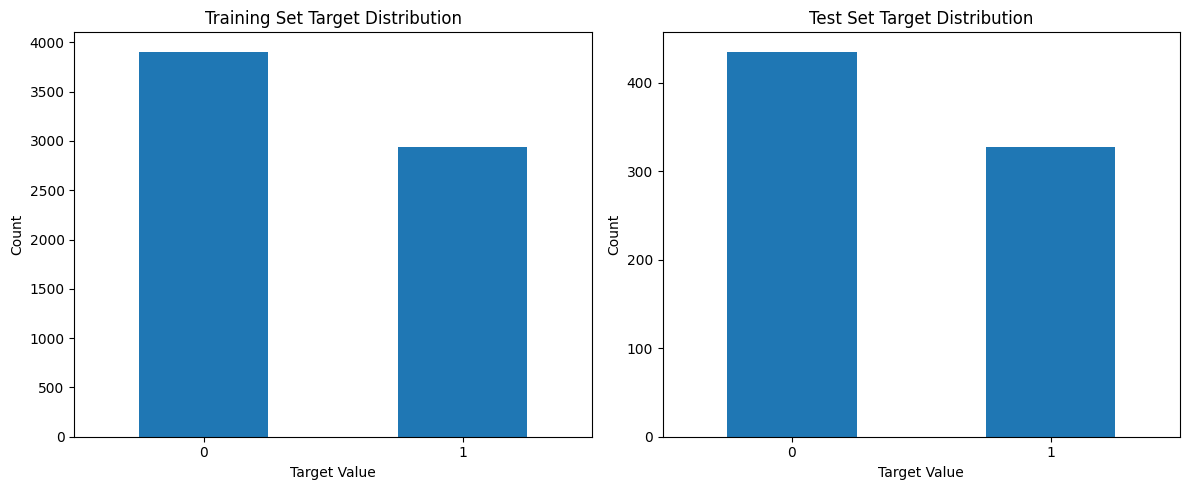

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot for training set target distribution
y_train.value_counts().plot(kind='bar', ax=axes[0], title='Training Set Target Distribution')
axes[0].set_xlabel('Target Value')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot for test set target distribution
y_test.value_counts().plot(kind='bar', ax=axes[1], title='Test Set Target Distribution')
axes[1].set_xlabel('Target Value')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Is the dataset balanced?
As shown in the plots above, the dataset is not entirely balanced, however it is not a bad dataset to work with.

## Q2 - Preprocess

In [32]:
x_train = x_train.drop(columns=['id', 'location'])
x_train = x_train.fillna('null')
x_train['inputs'] = x_train['keyword'] + ' ' + x_train['text']
x_test = x_test.drop(columns=['id', 'location'])
x_test = x_test.fillna('null')
x_test['inputs'] = x_test['keyword'] + ' ' + x_test['text']

## Q3 - Remove unnecessary information

In [42]:
# Remove any unicode strings
x_train['inputs'] = x_train['inputs'].apply(removeUnicode)
# Replace any URL with 'url' to improve model
x_train['inputs'] = x_train['inputs'].apply(replaceURL)
# Replace !!+ with a single !
x_train['inputs'] = x_train['inputs'].apply(replaceMultiExclamationMark)
# Replace ??+ with a single ?
x_train['inputs'] = x_train['inputs'].apply(replaceMultiQuestionMark)
# Replace ..+ with a single .
x_train['inputs'] = x_train['inputs'].apply(replaceMultiStopMark)
# Remove any emoticons
x_train['inputs'] = x_train['inputs'].apply(removeEmoticons)
# Remove any numbers
x_train['inputs'] = x_train['inputs'].apply(removeNumbers)

### Why did we use these preprocessing techniques?
The reason we used all these text preprocessing functions is to aid the models in their learning and produce better results. This allows a model not to be affected by a use of one URL over another, for example, and thus produce more stable and accurate results.

## Q4 - Turn inputs and targets into numpy arrays

In [43]:
inputs_train, inputs_test, targets_train, targets_test = np.array(x_train['inputs']), \
np.array(x_test['inputs']), np.array(y_train), np.array(y_test)

## Q5 - Perform TF-IDF vectorization

In [48]:
tfidf = TfidfVectorizer()
tfidf.fit(inputs_train, )
inputs_train_tf = tfidf.transform(inputs_train)
inputs_test_tf = tfidf.transform(inputs_test)

## Q6 - Classify using an SVM

In [61]:
svm = LinearSVC()
svm.fit(inputs_train_tf, targets_train)
svm_preds = svm.predict(inputs_test_tf)
precision, recall, fscore, _ = precision_recall_fscore_support(targets_test,
                                                               svm_preds)
accuracy = svm.score(inputs_test_tf, targets_test)
# print(accuracy, fscore, precision, recall)
print(f'Accuracy: {accuracy*100:.2f}%')
print(f'For target 0')
print(f'  F1 score: {fscore[0] * 100:.2f} %')
print(f'  Precision: {precision[0] * 100:.2f} %')
print(f'  Recall: {recall[0] * 100:.2f} %')
print(f'For target 1')
print(f'  F1 score: {fscore[1] * 100:.2f} %')
print(f'  Precision: {precision[1] * 110:.2f} %')
print(f'  Recall: {recall[1] * 100:.2f} %')

Accuracy: 78.22%
For target 0
  F1 score: 82.38 %
  Precision: 76.53 %
  Recall: 89.20 %
For target 1
  F1 score: 71.48 %
  Precision: 89.73 %
  Recall: 63.61 %


### What is the most important result from the above?
The most important result is the Recall score per class, as we are dealing with an imbalanced dataset, and therefore we are interested in predicting whether a natural disaster takes place or not. Therefore, we should focus on Recall, since we can deal with False Positives down the line, but the important thing is the safety of the people.

## Q7 - Perform PCA

In [72]:
pca = PCA(n_components=.95, svd_solver='full')
dense = inputs_train_tf.toarray()
pca.fit(dense)
inputs_train_pca = pca.transform(inputs_train_tf)
inputs_test_pca = pca.transform(inputs_test_tf)

In [75]:
svmrbf = SVC()
svmrbf.fit(inputs_train_pca, y_train)
svm.fit(inputs_train_pca, y_train)

LinearSVC()

In [80]:
linear_acc = svm.score(inputs_test_pca, y_test)
rbf_acc = svmrbf.score(inputs_test_pca, y_test)
linear_preds = svm.predict(inputs_test_pca)
rbf_preds = svmrbf.predict(inputs_test_pca)
l_p, l_r, l_f, _ = precision_recall_fscore_support(y_test, linear_preds)
r_p, r_r, r_f, _ = precision_recall_fscore_support(y_test, rbf_preds)

print('LINEAR SVM CLASSIFIER')
print(f'Accuracy: {linear_acc*100:.2f}%')
print(f'For target 0')
print(f'  F1 score: {l_f[0] * 100:.2f} %')
print(f'  Precision: {l_p[0] * 100:.2f} %')
print(f'  Recall: {l_r[0] * 100:.2f} %')
print(f'For target 1')
print(f'  F1 score: {l_f[1] * 100:.2f} %')
print(f'  Precision: {l_p[1] * 110:.2f} %')
print(f'  Recall: {l_r[1] * 100:.2f} %')
print()
print('RBF KERNEL SVM CLASSIFIER')
print(f'Accuracy: {rbf_acc*100:.2f}%')
print(f'For target 0')
print(f'  F1 score: {r_f[0] * 100:.2f} %')
print(f'  Precision: {r_p[0] * 100:.2f} %')
print(f'  Recall: {r_r[0] * 100:.2f} %')
print(f'For target 1')
print(f'  F1 score: {r_f[1] * 100:.2f} %')
print(f'  Precision: {r_p[1] * 110:.2f} %')
print(f'  Recall: {r_r[1] * 100:.2f} %')

LINEAR SVM CLASSIFIER
Accuracy: 80.97%
For target 0
  F1 score: 84.22 %
  Precision: 79.96 %
  Recall: 88.97 %
For target 1
  F1 score: 76.03 %
  Precision: 91.01 %
  Recall: 70.34 %

RBF KERNEL SVM CLASSIFIER
Accuracy: 81.76%
For target 0
  F1 score: 84.43 %
  Precision: 82.31 %
  Recall: 86.67 %
For target 1
  F1 score: 77.97 %
  Precision: 89.01 %
  Recall: 75.23 %


As shown in the results above, the RBF kernel based SVM performs by about 1% better in accuracy, and has an improved Recall score for label 1, which is what we are aiming for when trying to prevent lives being lost due to natural disasters.

## Q8 - What is the value of `γ` when it is set to `scale`, and what is its  value when set to `auto`?

In [85]:
scale_value = 1/(inputs_train_pca.shape[1] * inputs_train_pca.var())
auto_value = 1/(inputs_train_pca.shape[1])
print(f'Value of γ when it is set to `scale`: {scale_value}')
print(f'Value of γ when it is set to `auto` : {auto_value}')

Value of γ when it is set to `scale`: 1.0649298857402716
Value of γ when it is set to `auto` : 0.00024906600249066


Changing the value of `\gamma` from 'scale' to 'auto'.

In [88]:
svmrbfgamma = SVC(gamma='auto')
svmrbfgamma.fit(inputs_train_pca, y_train)
rbfgamma_acc = svmrbfgamma.score(inputs_test_pca, y_test)
rbfgamma_preds = svmrbfgamma.predict(inputs_test_pca)
rg_p, rg_r, rg_f, _ = precision_recall_fscore_support(y_test, rbfgamma_preds)

print('RBF KERNEL SVM CLASSIFIER')
print(f'Accuracy: {rbfgamma_acc*100:.2f}%')
print(f'For target 0')
print(f'  F1 score: {rg_f[0] * 100:.2f} %')
print(f'  Precision: {rg_p[0] * 100:.2f} %')
print(f'  Recall: {rg_r[0] * 100:.2f} %')
print(f'For target 1')
print(f'  F1 score: {rg_f[1] * 100:.2f} %')
print(f'  Precision: {rg_p[1] * 110:.2f} %')
print(f'  Recall: {rg_r[1] * 100:.2f} %')

RBF KERNEL SVM CLASSIFIER
Accuracy: 57.09%
For target 0
  F1 score: 72.68 %
  Precision: 57.09 %
  Recall: 100.00 %
For target 1
  F1 score: 0.00 %
  Precision: 0.00 %
  Recall: 0.00 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task
**Original User Task**:

Extract the accuracy, F1-score, precision, and recall for target 0 and target 1 for the following four SVM experiments: 'LinearSVC', 'LinearSVC after PCA', 'SVM with RBF after PCA', and 'SVM with RBF and gamma=auto after PCA'. Organize these metrics into a Pandas DataFrame. Generate two separate bar plots: one showing overall accuracy, F1-score for target 1, precision for target 1, and recall for target 1 for each model, and another showing F1-score for target 0, precision for target 0, and recall for target 0 for each model. Ensure both plots have appropriate labels, titles, and legends. Finally, summarize the key findings from both plots, emphasizing the recall for target 1, as it is critical for this problem.

## Extract and Organize Metrics

### Subtask:
Extract the accuracy, F1-score, precision, and recall for both target 0 and target 1 for all four SVM experiments: 'LinearSVC', 'LinearSVC after PCA', 'SVM with RBF after PCA', and 'SVM with RBF and gamma=auto after PCA'. Organize these metrics into a Pandas DataFrame for easy plotting.


**Reasoning**:
I will create a dictionary to store the metrics for each SVM model and then convert this dictionary into a Pandas DataFrame as requested in the subtask instructions.



In [95]:
metrics_data = {
    'LinearSVC': {
        'Accuracy': accuracy,
        'F1-score': fscore[1],
        'Precision': precision[1],
        'Recall': recall[1]
    },
    'LinearSVC after PCA': {
        'Accuracy': linear_acc,
        'F1-score': l_f[1],
        'Precision': l_p[1],
        'Recall': l_r[1]
    },
    'SVM with RBF after PCA': {
        'Accuracy': rbf_acc,
        'F1-score': r_f[1],
        'Precision': r_p[1],
        'Recall': r_r[1]
    },
    'SVM with RBF and gamma=auto after PCA': {
        'Accuracy': rbfgamma_acc,
        'F1-score': rg_f[1],
        'Precision': rg_p[1],
        'Recall': rg_r[1]
    }
}

metrics_df = pd.DataFrame.from_dict(metrics_data, orient='index')
metrics_df

,Accuracy,F1-score,Precision,Recall
LinearSVC,0.782152,0.714777,0.815686,0.636086
LinearSVC after PCA,0.809711,0.760331,0.827338,0.703364
SVM with RBF after PCA,0.817585,0.779715,0.809211,0.752294
SVM with RBF and gamma=auto after PCA,0.570866,0.000000,0.000000,0.000000


## Visualizing SVM Performance

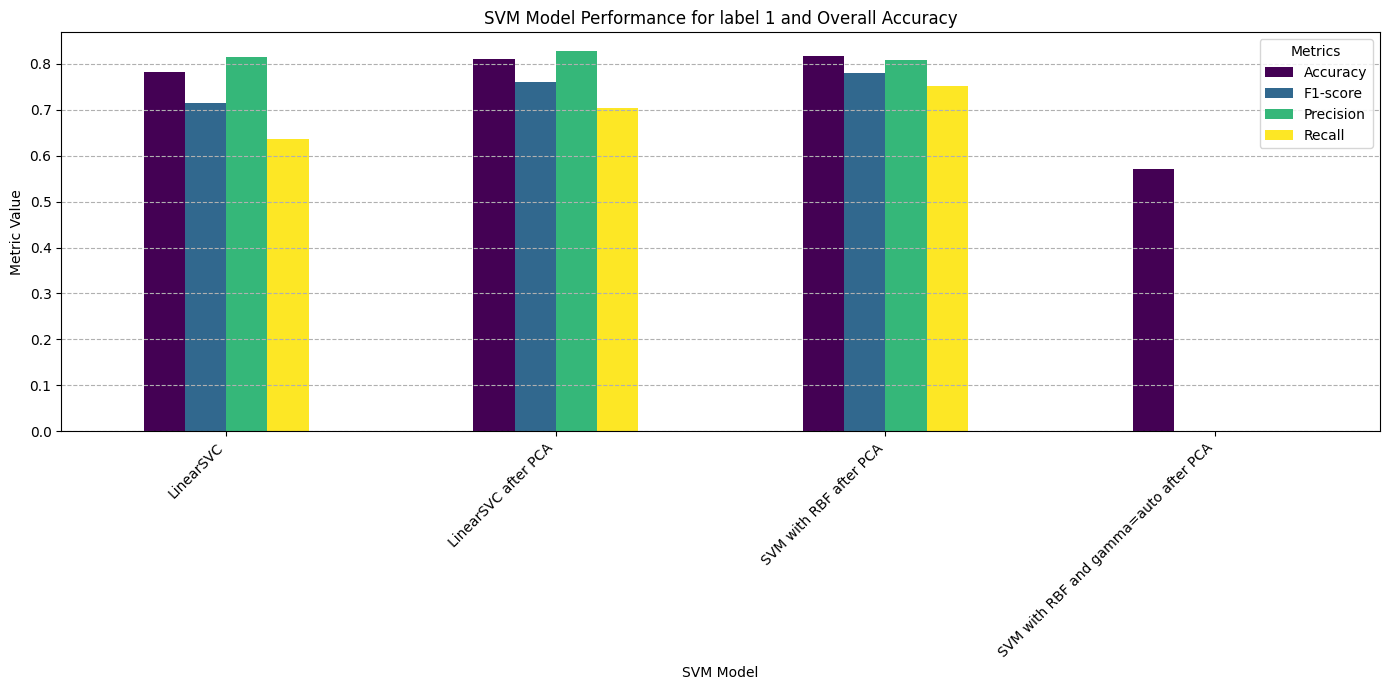

In [102]:
metrics = metrics_df[['Accuracy', 'F1-score', 'Precision', 'Recall']]

metrics.plot(kind='bar', figsize=(14, 7), colormap='viridis', )
plt.title('SVM Model Performance for label 1 and Overall Accuracy')
plt.xlabel('SVM Model')
plt.ylabel('Metric Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Notes on the plot above
One important thing to note in the plot above is how the value of Recall is at its maximum after using PCA on the data and solving using an RBF kernel. That is also the model with the highest F1 score. That model is the most adequate in predicting a natural disaster based on tweets.

## Q9 - Use Naive Bayes

In [107]:
bayes = GaussianNB()
bayes.fit(dense, targets_train)
dense_test = inputs_test_tf.toarray()
bayes_acc = bayes.score(dense_test, targets_test)
bayes_preds = bayes.predict(dense_test)
b_p, b_r, b_f, _ = precision_recall_fscore_support(targets_test, bayes_preds)

print('NAIVE BAYES CLASSIFIER')
print(f'Accuracy: {bayes_acc*100:.2f}%')
print(f'For target 0')
print(f'  F1 score: {b_f[0] * 100:.2f} %')
print(f'  Precision: {b_p[0] * 100:.2f} %')
print(f'  Recall: {b_r[0] * 100:.2f} %')
print(f'For target 1')
print(f'  F1 score: {b_f[1] * 100:.2f} %')
print(f'  Precision: {b_p[1] * 110:.2f} %')
print(f'  Recall: {b_r[1] * 100:.2f} %')

NAIVE BAYES CLASSIFIER
Accuracy: 57.22%
For target 0
  F1 score: 62.53 %
  Precision: 62.53 %
  Recall: 62.53 %
For target 1
  F1 score: 50.15 %
  Precision: 55.17 %
  Recall: 50.15 %


The Naive Bayes classifier is a good classifier to be used as a baseline. It has a 50% Recall on target 1, which is equivalent to flipping a coin to make predictions.